In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima


In [2]:
df = pd.read_csv("/workspaces/Elreno23-machine-learning-python-template/data/raw/10-time-series-forecasting-sales.csv")
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


### 1-Limpieza Inicial

In [ ]:
df.duplicated().sum()

np.int64(0)

### 2-Preparación de Datos

In [4]:
df["date"]=pd.to_datetime(df["date"])
df["date"] = df["date"].dt.date
df = df.set_index("date")
df


,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633
...,...
2023-08-30,989.600354
2023-08-31,994.987326
2023-09-01,995.814415


### Conclusiones

Convertimos nuestra columna date a formato datetime y luego a date para eliminar las horas y minutos. Indexamos date y obtenemos un df de una sola columna.

### 3-Visualización Inicial

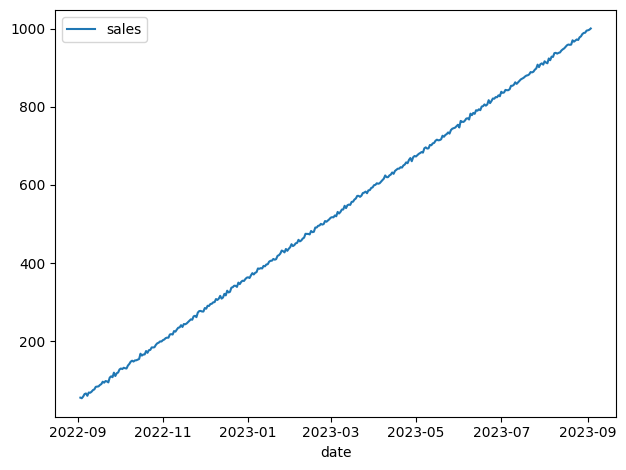

In [5]:
sns.lineplot(data=df)
plt.tight_layout()
plt.show()

### 4-Descomposición de la serie original
-Nos da una idea visual de tendencia y estacionalidad

In [6]:
descomposition = seasonal_decompose(df,period=12)
descomposition

##### Trend(Tendencia)

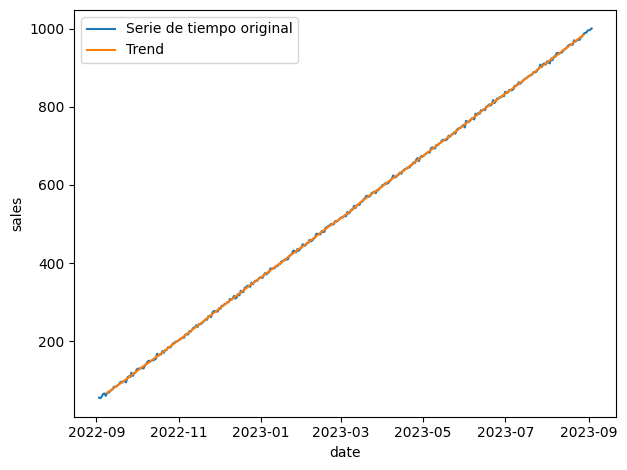

In [7]:
trend = descomposition.trend

sns.lineplot(x=df.index, y=df["sales"], label="Serie de tiempo original")
sns.lineplot(x=trend.index, y=trend.values, label="Trend")

plt.tight_layout()
plt.show()

##### Seasonal(Estacionalidad)

-Patrones repetitivos en intervalos irregulares

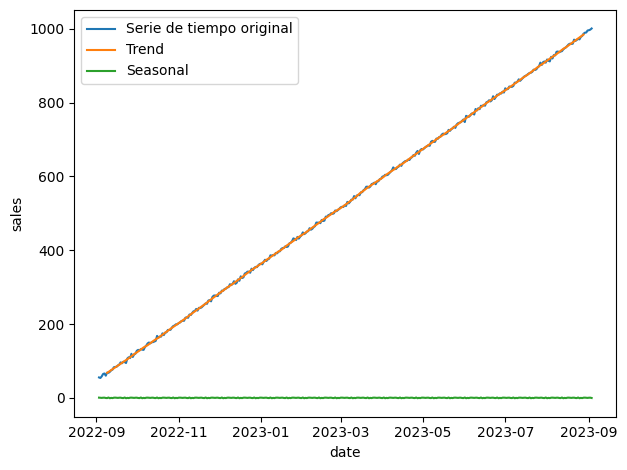

In [8]:
seasonal = descomposition.seasonal

sns.lineplot(x=df.index, y=df["sales"], label="Serie de tiempo original")
sns.lineplot(x=trend.index, y=trend.values, label="Trend")
sns.lineplot(x=seasonal.index,y=seasonal.values, label="Seasonal")

plt.tight_layout()
plt.show()

### 5-Test Dickey-Fuller aumentado

-Verificamos estacionariedad

In [9]:
def test_stationarity(timeseries):
    df_test = adfuller(timeseries, autolag="AIC")
    df_output = pd.Series(df_test[0:4], index=["Test Statistic", "p-value", "Lags Used", "Number of Observations Used"])
    for key, value in df_test[4].items():
        df_output[f'Critical Value {key}'] = value
    return df_output

result = test_stationarity(df)
result

Test Statistic                   0.545414
p-value                          0.986190
Lags Used                       13.000000
Number of Observations Used    352.000000
Critical Value 1%               -3.449065
Critical Value 5%               -2.869786
Critical Value 10%              -2.571163
dtype: float64

### Conclusiones
-Los valores que nos retorna el Test de Dickey-Fuller representan si la serie es estacionaria(valores estadisticos que cambian con el tiempo)
H0: NO estacionaria
H1: Estacionaria

Observamos que el valor p_value es muy alto por lo que no podemos rechazar H0(No es estacionaria)
Otra forma de verificar la estacionaridad es comparar el valor de Test Statistic con Critical Value 5% si este es mas negativo que el de Test Statistic quiere decir que rechazamos H0, la serie no es estacionaria


### 6-Diferenciación

-Estabilizamos la serie

In [10]:
df["diff_sales"] = df["sales"].diff()
sales_diff = df["diff_sales"].dropna()
sales_diff

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Name: diff_sales, Length: 365, dtype: float64

### Conclusiones

Calculamos la diferencia entre cada valor y el anterior, asi elimanamos la tendencia a largo plazo
Ejemplo: 
-Serie original: [100,120,140]
-Diferenciada: [NaN,20,20] -> Lo que logramos es que las propiedades estadisticas no cambien con el tiempo. Que sus valores se mantengan estables.



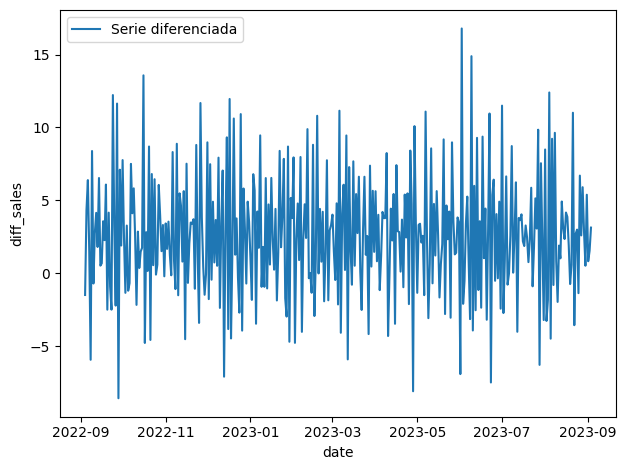

In [11]:
sns.lineplot(data=sales_diff, label="Serie diferenciada")
plt.tight_layout()
plt.show()

### 7-Test Dickey Fuller(Verificar Estacionaridad)

-Confirmamos que es esatcionaria

In [12]:
result_diff = test_stationarity(sales_diff)
result, result_diff

(Test Statistic                   0.545414
 p-value                          0.986190
 Lags Used                       13.000000
 Number of Observations Used    352.000000
 Critical Value 1%               -3.449065
 Critical Value 5%               -2.869786
 Critical Value 10%              -2.571163
 dtype: float64,
 Test Statistic                -9.430263e+00
 p-value                        5.212954e-16
 Lags Used                      1.200000e+01
 Number of Observations Used    3.520000e+02
 Critical Value 1%             -3.449065e+00
 Critical Value 5%             -2.869786e+00
 Critical Value 10%            -2.571163e+00
 dtype: float64)

### Conclusiones

Como podemos observar en este nuevo test podemos rechazar la H0, es decir, ahora la serie si es estacionaria, esto lo sabemos por los nuevos valores estadisticos. p-values es extremadamente bajo y Test Statistic es mucho mas negativo que Critical value 5%

### 8-Descomposición de la serie diferenciada

-Validamos como cambió al estructura despues de la transformación

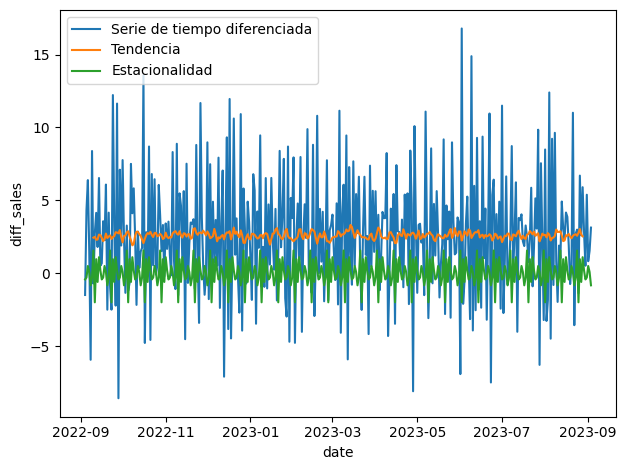

In [13]:
diff_descomposition= seasonal_decompose(sales_diff, period=12)
diff_descomposition_trend = diff_descomposition.trend
diff_descomposition_seasonal = diff_descomposition.seasonal
sns.lineplot(data=sales_diff,label="Serie de tiempo diferenciada")
sns.lineplot(data=diff_descomposition_trend,label="Tendencia")
sns.lineplot(data=diff_descomposition_seasonal,label="Estacionalidad")

plt.tight_layout()
plt.show()

In [14]:
df

,sales,diff_sales
date,,
2022-09-03,55.292157,NaN
2022-09-04,53.803211,-1.488946
2022-09-05,58.141693,4.338482
2022-09-06,64.530899,6.389205
2022-09-07,66.013633,1.482734
...,...,...
2023-08-30,989.600354,0.518681
2023-08-31,994.987326,5.386972
2023-09-01,995.814415,0.827090


### 9-Análisis de variabilidad

-residuo(Sin tendencia ni estacionalidad)
-Nos aseguramos que el ruido se comporta sin patrones claros

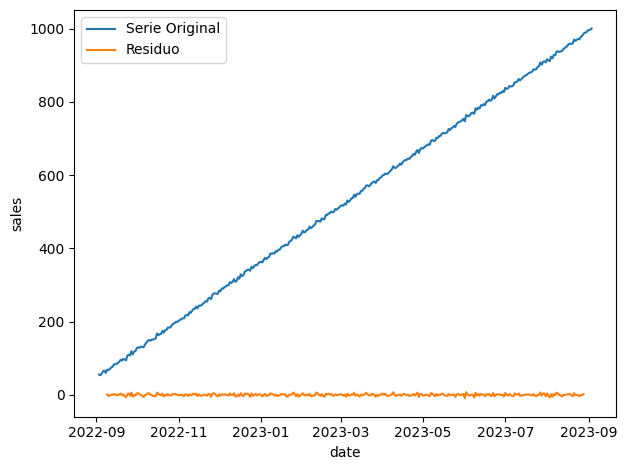

In [15]:
residual = descomposition.resid

sns.lineplot(x=df.index,y=df["sales"],label="Serie Original")
sns.lineplot(x=residual.index,y=residual.values,label="Residuo")

plt.tight_layout()
plt.show()


### Conclusiones

Residuo: Parte de la serie que no fue explicada por el modelo de descomposición

-Vemos la tendencia creciente de las ventas(linea azul)
-La linea naranja se mantiene en cero, lo que quiere decir que el modelo capturo bien la tendencia y estacionalidad, el residuo es minimo. el modelo está bien ajustado

#### 10-Análisis de la autocorrelación(ACF/PACF)

-Nos da una idea de los parametros a elegir para nuestro modelo


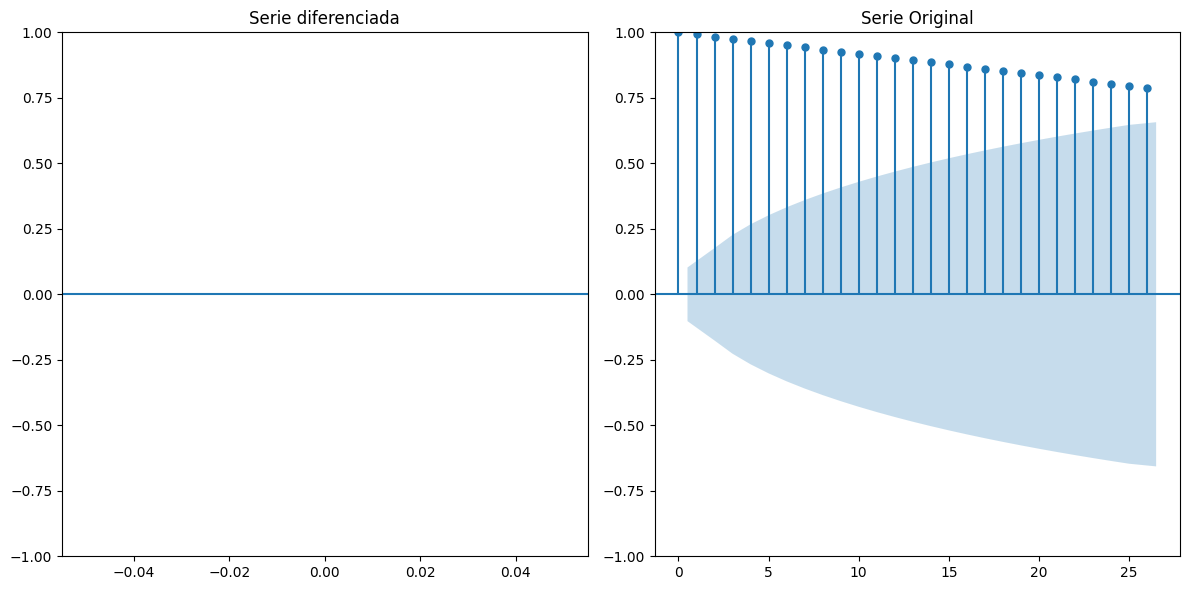

In [16]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
plot_acf(df["diff_sales"], ax=axs[0])
axs[0].set_title("Serie diferenciada")
plot_acf(df["sales"],ax=axs[1])
axs[1].set_title("Serie Original")
plt.tight_layout()
plt.show()

### Conclusiones

-Despues de aplicar la diferenciacion a la serie, esta se ha vuelto estacionaria mostrando propiedades estadisticas constantes en el tiempo como podemos obervar en el grafico d ela izquierda

-En el grafico de la derecha observamos la serie original y esta presenta una tendencia, es decir, sus propiedades estadisticas(media, varianza) cambian con el tiempo(No estacionaria) 

### 11-Modelado

-Automatizamos la selección de parámetros con auto_arima

In [17]:
model = auto_arima(sales_diff,seasonal=True,trace=True,m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1847.119, Time=2.19 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2096.542, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1972.854, Time=0.17 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2209.657, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=1845.127, Time=0.81 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=1843.049, Time=0.41 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=1845.092, Time=0.97 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=1843.587, Time=0.18 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=1841.533, Time=0.48 sec
 ARIMA(2,0,1)(1,0,0)[12] intercept   : AIC=1843.436, Time=1.07 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=1843.433, Time=1.27 sec
 ARIMA(2,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=1839.553, Time=0.40 sec
 ARIMA(1,0,1)(1,0,0)[12] inte

### Conclusiones

-auto_arima -> Busca el mejor ARIMA/SARIMA
-sales_diff -> Serie temporal
-seasonal=True -> Incluye estacionalidad
-trace=true -> Muestra el proceso
-m=12 -> Ciclo estacional de 12 pasos(anual en datos mensuales)

##### Informe estadistico

In [18]:
model.summary() #Nos da un "informe" estadistico del modelo

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -915.776
Date:                Mon, 08 Dec 2025   AIC                           1839.553
Time:                        21:37:10   BIC                           1855.152
Sample:                    09-04-2022   HQIC                          1845.752
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8110      0.134     21.055      0.000       2.549       3.073
ar.L1         -0.0821      0.052     -1.592      0.111      -0.183       0.019
ma.L1         -0.9413      0.020    -47.701      0.000      -0.980      -0.903
sigma2         8.7903      0.688     12.777      0.000       7.442      10.139
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.76
Prob(Q):                              1.00   Prob(JB):                         0.68
Heteroskedasticity (H):               0.90   Skew:                             0.07
Prob(H) (two-sided):                  0.58   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##### 12-Generamos una proyección de al serie diferenciada

In [19]:
prediccion = model.predict(12)
prediccion

2023-09-04    1.675366
2023-09-05    2.673520
2023-09-06    2.591621
2023-09-07    2.598341
2023-09-08    2.597789
2023-09-09    2.597834
2023-09-10    2.597831
2023-09-11    2.597831
2023-09-12    2.597831
2023-09-13    2.597831
2023-09-14    2.597831
2023-09-15    2.597831
Freq: D, dtype: float64

#### Conclusiones
Valores pronosticados para cada fecha constantes

##### 13-Graficamos la serie diferenciada con la prediccion

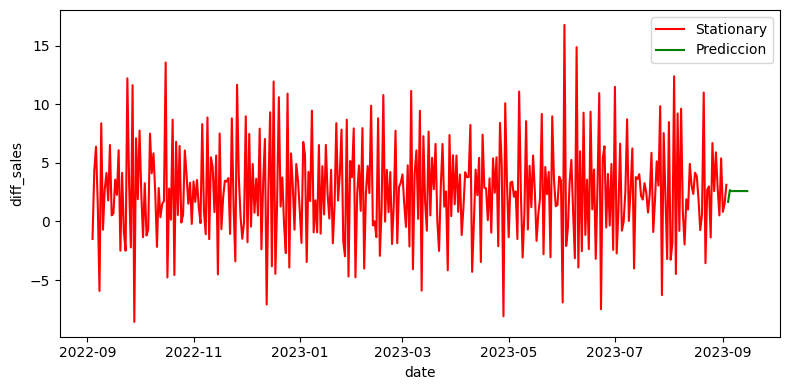

In [20]:
figs,axs=plt.subplots(figsize=(8,4))

sns.lineplot(data=sales_diff, label="Stationary", color="red")
sns.lineplot(data=prediccion, label="Prediccion", color="green")

plt.tight_layout()
plt.show()

##### 14-Revertimos la diferenciacion 

In [21]:
#Ultimo valor de la serie orignal antes de diferenciar
last_value = df["sales"].iloc[-1]

#Reconstruir las predicciones a partir del utlimo valor conocido

forecast = prediccion.cumsum() + last_value
#cumsum(): Devuelve una nueva serie donde cada posición es la suma acumulada hasta ese punto.


### Conclusiones

-La diferenciación es un paso tecnico para que la serie sea estacionaria(propiedades estadisticas constantes) y asi el modelo pueda trabajr bien, pero lo que nos interesa es predecir las ventas originales, por eso hay que revertir las diferenciación

-Obtenemos el ultimo valor de la columna "sales"(columna original estacionaria)

-Obtenemos la suma acumulada de la prediccion de la serie no estacionaria mas este ultimo valor

-Estamos prediciendo las diferencias de las ventas originales, a partir del ultimo valor original


##### 15-Graficamos la prediccion con al serie original

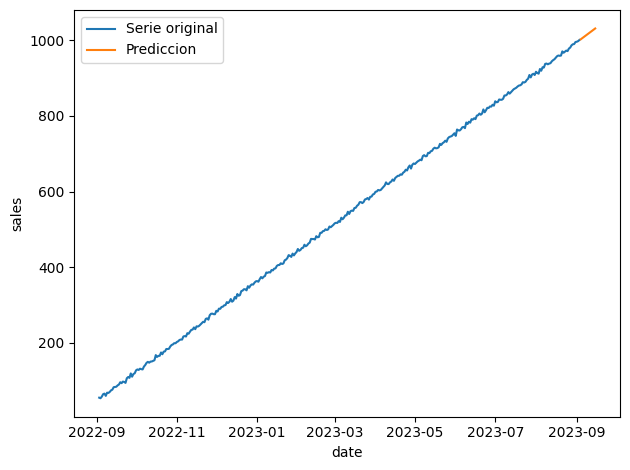

In [22]:
sns.lineplot(data=df["sales"], label="Serie original")
sns.lineplot(data=forecast, label="Prediccion")

plt.tight_layout()
plt.show()

### Conclusiones

-El modelo captó al tendencia y sigue la trayectoria ascendete de la serie original